# Visualise all the locations

In [2]:
import pickle

import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from networks import PrimalNetEndToEnd  # make sure this is importable
# from gep_config_parser import parse_config  # only if you really need it

from gep_config_parser import parse_config

In [5]:
CONFIG_FILE_NAME = "config.toml"
data_path = f"experiment-output/ch5/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
data = pickle.load(open(data_path, 'rb'))

input_data = parse_config(CONFIG_FILE_NAME) # Reads the input data using config.toml's experiment.inputs.data path.

gep_ed_data = input_data["experiment"]["experiments"][0]

In [6]:
print(gep_ed_data.keys())

dict_keys(['representative_period_weight', 'value_of_lost_load', 'ramping_value', 'demand_data', 'generation_data', 'generation_availability_data', 'transmission_lines_data', 'times', 'nodes', 'generators', 'transmission_lines', 'crossover', 'rounding', 'output_file', 'output_log', 'ramping', 'relaxed'])


In [7]:
print(f"All the locations:")
print(gep_ed_data["nodes"])
print(f"Lines between locations:")
print(gep_ed_data["transmission_lines"])

All the locations:
['AUS', 'BEL', 'BLK', 'BLT', 'CZE', 'DEN', 'FIN', 'FRA', 'GER', 'IRE', 'ITA', 'NED', 'NOR', 'POL', 'POR', 'SKO', 'SPA', 'SWE', 'SWI', 'UKI']
Lines between locations:
[('AUS', 'BLK'), ('AUS', 'CZE'), ('AUS', 'GER'), ('AUS', 'ITA'), ('AUS', 'SWI'), ('BEL', 'FRA'), ('BEL', 'GER'), ('BEL', 'NED'), ('BEL', 'UKI'), ('BLK', 'ITA'), ('BLK', 'SKO'), ('BLT', 'FIN'), ('BLT', 'POL'), ('BLT', 'SWE'), ('CZE', 'GER'), ('CZE', 'SKO'), ('DEN', 'NED'), ('DEN', 'NOR'), ('DEN', 'SWE'), ('DEN', 'UKI'), ('FIN', 'SWE'), ('FRA', 'IRE'), ('FRA', 'ITA'), ('FRA', 'UKI'), ('GER', 'DEN'), ('GER', 'FRA'), ('GER', 'NED'), ('GER', 'NOR'), ('GER', 'SWE'), ('GER', 'UKI'), ('NED', 'NOR'), ('NED', 'UKI'), ('NOR', 'UKI'), ('POL', 'CZE'), ('POL', 'GER'), ('POL', 'SKO'), ('POL', 'SWE'), ('SPA', 'FRA'), ('SPA', 'POR'), ('SWE', 'NOR'), ('SWI', 'FRA'), ('SWI', 'GER'), ('SWI', 'ITA'), ('UKI', 'IRE')]


In [8]:
# print(gep_ed_data["genenodesrators"]) 
# Get the one with (NED,*)
# Filter the list for tuples starting with 'NED'


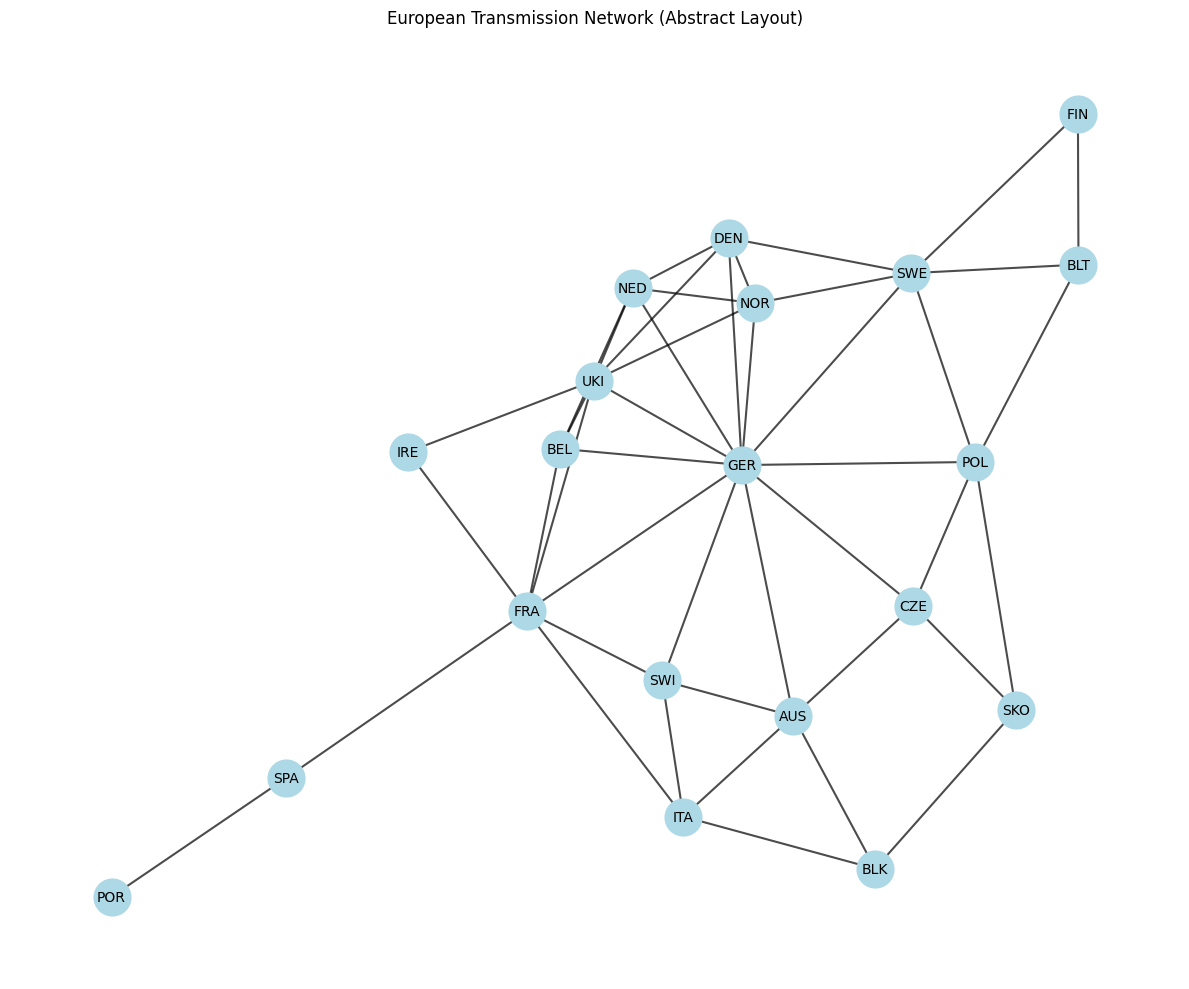

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Your data
nodes = gep_ed_data["nodes"]
edges = gep_ed_data["transmission_lines"]

# Build graph
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Layout
pos = nx.spring_layout(G, seed=42)  # reproducible

# Plot
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("European Transmission Network (Abstract Layout)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [10]:
!pwd

/Users/peterhuang/Desktop/Delft/Year-2/THESIS/MasterThesis-GraphPDL


In [11]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_subgraph(
    nodes,
    edges,
    selected_nodes,
    layout_seed=42,
    figsize=(6, 4),
    node_size=800,
    node_color="lightblue",
    edge_width=2.0,
):
    """
    Plot only selected nodes and edges between them.

    nodes: list of all nodes
    edges: list of (u, v) edges
    selected_nodes: list or set of nodes to plot
    """

    # Build full graph
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Induced subgraph
    SG = G.subgraph(selected_nodes).copy()

    # Layout on subgraph only
    pos = nx.spring_layout(SG, seed=layout_seed)

    # Plot
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(SG, pos, node_size=node_size, node_color=node_color)
    nx.draw_networkx_edges(SG, pos, width=edge_width)
    nx.draw_networkx_labels(SG, pos, font_size=10)

    plt.title(f"Subgraph ({len(SG.nodes)} nodes)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


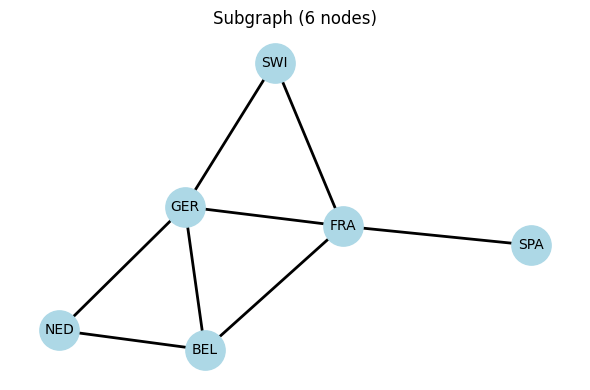

In [12]:
selected = ["GER", "FRA", "NED", "BEL","SPA","SWI"]
plot_subgraph(nodes, edges, selected)



## Select a 4th country

To join original experiment with:
- BEL
- GER
- FRA

In [13]:
ned_generators = [gen for gen in gep_ed_data["generators"] if gen[0] == 'SWI']
print("Generators in SWI:")
print(ned_generators)
print(f"Lines with SWI:")
swiss_lines = [line for line in gep_ed_data["transmission_lines"] if 'SWI' in line]
print(swiss_lines)

Generators in SWI:
[('SWI', 'Nuclear'), ('SWI', 'SunPV'), ('SWI', 'WindOff'), ('SWI', 'WindOn')]
Lines with SWI:
[('AUS', 'SWI'), ('SWI', 'FRA'), ('SWI', 'GER'), ('SWI', 'ITA')]


In [14]:
def plot_data_topology(data_path, name):
    data = pickle.load(open(data_path, 'rb'))
    print(data.N)
    print(data.L)

    # Build graph
    nodes = data.N
    edges = data.L
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Layout
    pos = nx.spring_layout(G, seed=42)  # reproducible

    # Plot
    plt.figure(figsize=(6, 4))
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
    nx.draw_networkx_labels(G, pos, font_size=10)

    plt.title("European Transmission Network 4 Node")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

['BEL', 'GER', 'FRA', 'SWI']
[('BEL', 'GER'), ('BEL', 'FRA'), ('GER', 'FRA'), ('SWI', 'FRA'), ('SWI', 'GER')]


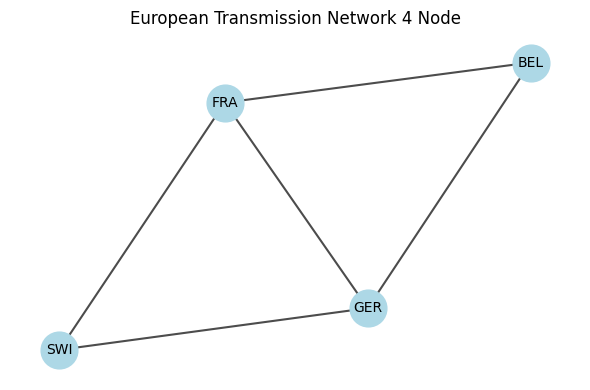

In [15]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F-S_GB2-G2-F2-S2_L5_c0_s0_p0_smp15.pkl", name="Transmission Network Topology")

['BEL', 'GER', 'FRA', 'SPA']
[('BEL', 'GER'), ('BEL', 'FRA'), ('GER', 'FRA'), ('SPA', 'FRA')]


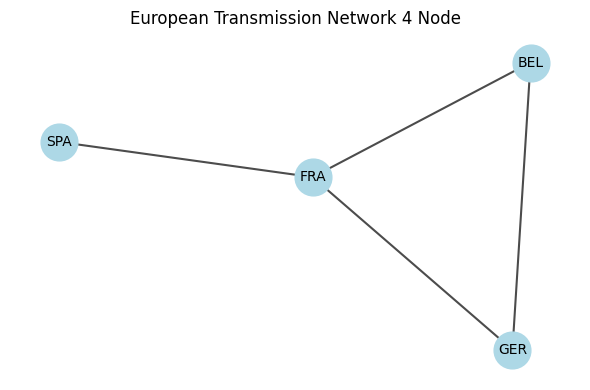

In [16]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_smp15.pkl", name="Transmission Network Topology")

### Evaluate DataSet Optimal Solution

In [11]:
import torch

In [12]:
const_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl"
const_data = pickle.load(open(const_data_path, 'rb')) 

In [13]:
const_data

In [14]:
''' 
Y value contains
[p, f, md]
Compute the unmet demand contribution + generation contribution of total cost
'''
print(f"Num Loc: {len(const_data.N)}, Num Gen: {len(const_data.G)}, Num Lines: {len(const_data.L)}")
print(f"Y shape: {const_data.opt_targets['y_operational'].shape}")
const_Y = const_data.opt_targets['y_operational']
const_X = const_data.X
print(f"X shape: {const_X.shape} Y shape: {const_Y.shape}")


Num Loc: 3, Num Gen: 6, Num Lines: 3
Y shape: torch.Size([32768, 12])
X shape: torch.Size([32768, 9]) Y shape: torch.Size([32768, 12])


In [15]:
def obj_compute(data, X, Y):
    p_gt, f_lt, md_nt = data.split_dec_vars_from_Y(Y)

    p_gt = torch.abs(p_gt)
    
    cost = data.cost_vec @ p_gt.T

    load_shedding = data.pVOLL * torch.norm(md_nt, p=1, dim=1)

    return  cost, load_shedding, cost + load_shedding


In [16]:
prod_cost, unmet_cost, const_obj = obj_compute(const_data, const_X, const_Y)
percentage_unmet = (unmet_cost / const_obj) * 100
print(f"For the Constraint Dataset")
print("Mean % unmet:", percentage_unmet.mean().item())
print("Median % unmet:", percentage_unmet.median().item())
print("P90 % unmet:", percentage_unmet.quantile(0.9).item())
print(percentage_unmet)

For the Constraint Dataset
Mean % unmet: 58.372423656478226
Median % unmet: 97.06959453466577
P90 % unmet: 99.79235665479294
tensor([98.8613, 99.8470,  0.0000,  ..., 98.3612,  0.0000, 98.8102],
       dtype=torch.float64)


In [17]:
const_renew_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvFalse.pkl"
const_renew_data = pickle.load(open(const_renew_data_path, 'rb'))
const_renew_X = const_renew_data.X
const_renew_Y = const_renew_data.opt_targets['y_operational']
prod_cost, unmet_cost, const_obj = obj_compute(const_renew_data, const_renew_X, const_renew_Y)
percentage_unmet = (unmet_cost / const_obj) * 100
print(f"For the Renewable Constraint Dataset")
print("Mean % unmet:", percentage_unmet.mean().item())
print("Median % unmet:", percentage_unmet.median().item())
print("P90 % unmet:", percentage_unmet.quantile(0.9).item())
print(percentage_unmet)

For the Renewable Constraint Dataset
Mean % unmet: 55.443882948800876
Median % unmet: 96.04077284642267
P90 % unmet: 99.78412298922584
tensor([98.7888,  0.0000, 99.9346,  ...,  0.0000,  0.0000,  0.0000],
       dtype=torch.float64)


### UnConstraint Data (Original Data)

In [18]:
noconst_data_path = f"experiment-output/ch5/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
noconst_data = pickle.load(open(noconst_data_path, 'rb')) 

noconst_Y = noconst_data.opt_targets['y_operational']
noconst_X = noconst_data.X

no_prod_cost, no_unmet_cost, no_const_obj = obj_compute(noconst_data, noconst_X, noconst_Y)
# print(f"Objective value: {no_const_obj}")

no_percentage_unmet = (no_unmet_cost / no_const_obj) * 100
print("Mean % unmet:", no_percentage_unmet.mean().item())
print("Median % unmet:", no_percentage_unmet.median().item())
print("P90 % unmet:", no_percentage_unmet.quantile(0.9).item())
print(no_percentage_unmet)

Mean % unmet: 14.722751311154362
Median % unmet: 0.0
P90 % unmet: 98.52645512512487
tensor([0., 0., 0.,  ..., 0., 0., 0.], dtype=torch.float64)


### Constrained LB Data

In [19]:
# const_LB_data_path = "data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbTrue.pkl"
# const_LB_data = pickle.load(open(const_LB_data_path, 'rb')) 

# const_LB_Y = const_LB_data.opt_targets['y_operational']
# const_LB_X = const_LB_data.X

# prod_LB_cost, unmet_LB_cost, const_LB_obj = obj_compute(const_LB_data, const_LB_X, const_LB_Y)


# percentage_LB_unmet = (unmet_LB_cost / const_LB_obj) * 100
# print(f"For the Constraint Dataset")
# print("Mean % unmet:", percentage_LB_unmet.mean().item())
# print("Median % unmet:", percentage_LB_unmet.median().item())
# print("P90 % unmet:", percentage_LB_unmet.quantile(0.9).item())
# print(percentage_LB_unmet)

### Constrained UB with 10000 renewables

In [20]:
const_LB_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl"
const_LB_data = pickle.load(open(const_LB_data_path, 'rb')) 

const_LB_Y = const_LB_data.opt_targets['y_operational']
const_LB_X = const_LB_data.X

prod_LB_cost, unmet_LB_cost, const_LB_obj = obj_compute(const_LB_data, const_LB_X, const_LB_Y)


percentage_LB_unmet = (unmet_LB_cost / const_LB_obj) * 100
print(f"For the Constraint Dataset")
print("Mean % unmet:", percentage_LB_unmet.mean().item())
print("Median % unmet:", percentage_LB_unmet.median().item())
print("P90 % unmet:", percentage_LB_unmet.quantile(0.9).item())
print(percentage_LB_unmet)

print(const_LB_data.pUnitInvestment.max(dim = 0))

FileNotFoundError: [Errno 2] No such file or directory: 'data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl'

In [21]:
const_LB_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc90.pkl"
const_LB_data = pickle.load(open(const_LB_data_path, 'rb')) 

const_LB_Y = const_LB_data.opt_targets['y_operational']
const_LB_X = const_LB_data.X

prod_LB_cost, unmet_LB_cost, const_LB_obj = obj_compute(const_LB_data, const_LB_X, const_LB_Y)


percentage_LB_unmet = (unmet_LB_cost / const_LB_obj) * 100
print(f"For the Constraint Dataset")
print("Mean % unmet:", percentage_LB_unmet.mean().item())
print("Median % unmet:", percentage_LB_unmet.median().item())
print("P90 % unmet:", percentage_LB_unmet.quantile(0.9).item())
print(percentage_LB_unmet)

print(const_LB_data.pUnitInvestment.max(dim = 0))

FileNotFoundError: [Errno 2] No such file or directory: 'data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc90.pkl'

## Plot Const Data for Thesis

In [22]:
print(const_data)
print(const_X.shape)
print(const_Y.shape)
print(const_data.pUnitInvestment.max(dim = 0))
print(const_data.G)

torch.Size([32768, 9])
torch.Size([32768, 12])
torch.return_types.max(
values=tensor([999.9949,  59.0929, 303.4958, 999.9780,  75.5273, 999.9828],
       dtype=torch.float64),
indices=tensor([30427, 22686, 18283,  8928, 26594, 11509]))
[('BEL', 'WindOff'), ('BEL', 'Gas'), ('GER', 'Gas'), ('GER', 'SunPV'), ('FRA', 'Nuclear'), ('FRA', 'SunPV')]


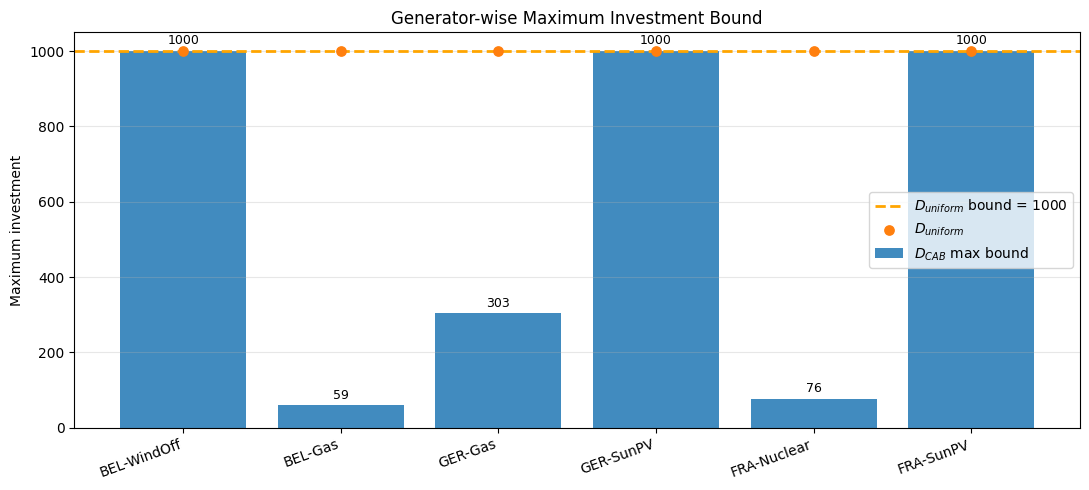

In [23]:
import numpy as np
import matplotlib.pyplot as plt

max_vals, _ = const_data.pUnitInvestment.max(dim=0)
max_vals = max_vals.detach().cpu().numpy()

labels = [f"{country}-{tech}" for country, tech in const_data.G]
x = np.arange(len(labels))
old_uniform_bound = 1000

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(x, max_vals, alpha=0.85, label=r"$D_{CAB}$ max bound")
ax.axhline(
    y=old_uniform_bound,
    linestyle="--",
    linewidth=2,
    color="orange",
    label=rf"$D_{{uniform}}$ bound = {old_uniform_bound}"
)

ax.scatter(
    x,
    np.full(len(labels), old_uniform_bound),
    s=45,
    zorder=3,
    label=r"$D_{uniform}$"
)

for rect, val in zip(bars, max_vals):
    ax.text(
        rect.get_x() + rect.get_width()/2,
        rect.get_height() + 10,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Maximum investment")
ax.set_title(r"Generator-wise Maximum Investment Bound")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Apparently, in the Unconstrained data, the unmet demand represent a much lower percentage of the overall cost, meaning learning to produce is the most improatnt thing for most of the cases.

### Load a Benders investment Data to check

In [24]:
# import ast
# info_csv_path = "outputs/Benders/3Node//experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_run_name:train:0.8_rho:0.5_rhomax:5000_alpha:10_Baseline.csv" 
# benders_df = pd.read_csv(info_csv_path)
# print(benders_df['investments'])
# benders_inv = np.array(benders_df["investments"].apply(ast.literal_eval).tolist(), dtype=float)
# print(benders_inv.shape)   # [num_samples, num_generators]
import glob
import ast  
def load_dist_investment(folder_path):
    # glob all csv files in the folder

    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    inv_list = []
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        if "investment" in df.columns:
            inv_list.extend(df["investment"].apply(ast.literal_eval).tolist())
    return np.array(inv_list, dtype=float)


exact_benders_path = "outputs/Benders/3Node/iter_logs_inexact_refine_Exact_Solve"
exact_inv = load_dist_investment(folder_path=exact_benders_path)
exact_inv.shape

(0,)

In [25]:
inexact_noLB_renew_path = "outputs/Benders/3Node/iter_logs_inexact_refine_ConstraintRenewablesUBFlex"
inexact_renew_inv = load_dist_investment(folder_path=inexact_noLB_renew_path)
inexact_renew_inv.shape

(0,)

In [26]:
exact_csv_path = "experiment-output/ch7/3nodes/benders_test_data_exact/experiment_data_sample_duration:120_start_exact:True_exact_refinement:False_run_name:train:0.8_rho:0.5_rhomax:5000_alpha:10.csv" 
exact_benders_df = pd.read_csv(exact_csv_path)
opt_investment = np.array(exact_benders_df["investments"].apply(ast.literal_eval).tolist(), dtype=float)
# print(exact_benders_inv.shape)   # [num_samples, num_generators]
# print(exact_benders_df["investments"].shape)

NameError: name 'pd' is not defined

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_generator_histograms(inv, generator_names=None, bins=20, title="Investment distributions"):
    inv = np.asarray(inv, dtype=float)
    num_g = inv.shape[1]

    if generator_names is None:
        generator_names = [f"G{i}" for i in range(num_g)]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for g in range(num_g):
        axes[g].hist(inv[:, g], bins=bins, alpha=0.8)
        axes[g].set_title(str(generator_names[g]))
        axes[g].set_xlabel("Investment")
        axes[g].set_ylabel("Count")
        axes[g].grid(True)

    # hide unused axes if num_g < 6
    for g in range(num_g, len(axes)):
        axes[g].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [28]:
# plot_generator_histograms(
#     benders_inv,
#     generator_names=[str(g) for g in const_data.G],
#     bins=20,
#     title="Benders investment distribution per generator"
# )

### Compare differeent Investment Data

In [29]:
constrained_inv = const_data.pUnitInvestment.cpu().numpy()
print(constrained_inv.shape)

constrained_lb_inv = const_LB_data.pUnitInvestment.cpu().numpy()
print(constrained_lb_inv.shape)

unconstrained_inv = noconst_data.pUnitInvestment.cpu().numpy()
print(unconstrained_inv.shape)

(32768, 6)


NameError: name 'const_LB_data' is not defined

In [30]:
import numpy as np
import pandas as pd

def summarize_investment(inv, name="dataset", zero_tol=1e-8):
    inv = np.asarray(inv, dtype=float)

    total_inv = inv.sum(axis=1)
    active_count = (np.abs(inv) > zero_tol).sum(axis=1)

    summary = {
        "dataset": name,
        "num_samples": inv.shape[0],
        "num_generators": inv.shape[1],
        "overall_mean": inv.mean(),
        "overall_median": np.median(inv),
        "overall_min": inv.min(),
        "overall_max": inv.max(),
        "fraction_zero": (np.abs(inv) <= zero_tol).mean(),
        "mean_total_investment": total_inv.mean(),
        "median_total_investment": np.median(total_inv),
        "min_total_investment": total_inv.min(),
        "max_total_investment": total_inv.max(),
        "mean_active_generators": active_count.mean(),
        "median_active_generators": np.median(active_count),
    }
    return pd.Series(summary, name=name)


def summarize_investments_table(investment_sets, zero_tol=1e-8, decimals=2):
    """
    Accepts either:
      - dict: {"benders": benders_inv, "constrained": constrained_inv}
      - list of tuples: [("benders", benders_inv), ("constrained", constrained_inv)]

    Returns:
      DataFrame with metrics as rows and dataset names as columns.
    """
    if isinstance(investment_sets, dict):
        items = investment_sets.items()
    else:
        items = investment_sets

    summaries = []
    for name, inv in items:
        s = summarize_investment(inv, name=name, zero_tol=zero_tol)
        summaries.append(s)

    df = pd.concat(summaries, axis=1)

    # keep text row as text, round numeric rows
    for idx in df.index:
        if idx != "dataset":
            df.loc[idx] = pd.to_numeric(df.loc[idx], errors="coerce").round(decimals)

    return df

In [31]:
table = summarize_investments_table({
    # "benders": benders_inv,
    "constrained": constrained_inv,
    "constrained_lb": constrained_lb_inv,
    "unconstrained": unconstrained_inv,
})

table


NameError: name 'constrained_lb_inv' is not defined

In [32]:
print(summarize_investments(constrained_inv, "constrained"))

NameError: name 'summarize_investments' is not defined

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_total_investment_hist(investment_sets, bins=40, title="Total investment per sample"):
    plt.figure(figsize=(9, 6.5))

    for name, inv in investment_sets.items():
        inv = np.asarray(inv, dtype=float)
        total_inv = inv.sum(axis=1)
        plt.hist(total_inv, bins=bins, alpha=0.45, label=name, density=True)

    plt.xlabel("Total investment")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [34]:
plot_total_investment_hist({
    "opt_investment": opt_investment,

    "exact_benders":exact_inv,
    "inexact_renew": inexact_renew_inv,
    # "constrained": constrained_inv,
    # # "constrained_lb_inv": constrained_lb_inv,
    # "unconstrained": unconstrained_inv,
})

NameError: name 'opt_investment' is not defined

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def plot_individual_investment_hist(
    investment_sets,
    bins=40,
    title="Investment per generator",
    layout=(2, 3),
    percentile_clip=(1, 99),
    density=False
):
    first_inv = np.asarray(next(iter(investment_sets.values())), dtype=float)
    n_generators = first_inv.shape[1]

    nrows, ncols = layout
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    for g in range(n_generators):
        ax = axes[g // ncols, g % ncols]

        # gather all methods for this generator to compute common plotting range
        all_vals = []
        for inv in investment_sets.values():
            inv = np.asarray(inv, dtype=float)
            all_vals.append(inv[:, g])
        all_vals = np.concatenate(all_vals)

        lo, hi = np.percentile(all_vals, percentile_clip)

        for name, inv in investment_sets.items():
            inv = np.asarray(inv, dtype=float)
            vals = inv[:, g]
            ax.hist(vals, bins=bins, range=(lo, hi), alpha=0.45, label=name, density=density)

        ax.set_title(f"Generator {g+1}")
        ax.set_xlabel("Investment")
        ax.set_ylabel("Density" if density else "Count")
        ax.grid(True)

    for k in range(n_generators, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 0.98))
    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

In [36]:
for name, inv in {
    "opt_investment": opt_investment,
    "exact_benders": exact_inv,
    "inexact_renew": inexact_renew_inv,
}.items():
    arr = np.asarray(inv, dtype=float)
    print(name, arr.shape, arr.ndim)

NameError: name 'opt_investment' is not defined

In [37]:
plot_individual_investment_hist({
    "opt_investment": opt_investment,
    "exact_benders": exact_inv,
    "inexact_renew": inexact_renew_inv,
}, bins=40, layout=(2, 3))

NameError: name 'opt_investment' is not defined

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def plot_generator_box_compare(
    investment_sets,
    generator_names=None,
    showfliers=True,
):
    first_inv = next(iter(investment_sets.values()))
    num_g = np.asarray(first_inv, dtype=float).shape[1]

    if generator_names is None:
        generator_names = [f"G{i}" for i in range(num_g)]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for g in range(num_g):
        data_list = []
        labels = []

        for name, inv in investment_sets.items():
            inv = np.asarray(inv, dtype=float)
            data_list.append(inv[:, g])
            labels.append(name)

        axes[g].boxplot(
            data_list,
            labels=labels,
            showfliers=showfliers,
            patch_artist=True,
        )

        # optional colors
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
        for patch, color in zip(axes[g].artists, colors[:len(data_list)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        axes[g].set_title(str(generator_names[g]))
        axes[g].tick_params(axis="x", rotation=20)
        axes[g].set_ylabel("Investment")
        axes[g].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [39]:
plot_generator_box_compare(
    {
        "constrained": constrained_inv,
        "constrained_lb_inv": constrained_lb_inv,
        # "unconstrained": unconstrained_inv,
    },
    generator_names=[str(g) for g in const_data.G],
    showfliers=False,
)

NameError: name 'constrained_lb_inv' is not defined

## Look at proper bound for rewnewables

In [40]:
noconst_data.T

range(1, 8761)

In [41]:
import torch

def renewable_availability_tensor(data, renewable_types=("WindOff", "SunPV","WindOn"), default_ava=1.0):
    """
    data.G: list like [(loc, tech), ...]
    data.T: iterable of timesteps (e.g., range or list)
    data.pGenAva: dict keyed by (loc, tech, t) -> availability in [0,1]

    Returns:
      ava_tensor: torch.Tensor shape [N_renew, T]
      renew_gens: list of (loc, tech) matching rows
      T_list: list of timesteps matching columns
    """
    # Collect renewable generators (preserve order)
    renew_gens = [(loc, tech) for (loc, tech) in data.G if tech in set(renewable_types)]
    T_list = list(data.T)

    N = len(renew_gens)
    Tn = len(T_list)

    ava = torch.empty((N, Tn), dtype=torch.float64)

    for i, (loc, tech) in enumerate(renew_gens):
        for j, t in enumerate(T_list):
            ava[i, j] = float(data.pGenAva.get((loc, tech, t), default_ava))

    return ava, renew_gens, T_list

In [42]:
ava_tensor, renew_gens, T_list = renewable_availability_tensor(noconst_data)
print(ava_tensor.shape)   # (N_renew, T)
print(renew_gens)         # row labels

torch.Size([3, 8760])
[('BEL', 'WindOff'), ('GER', 'SunPV'), ('FRA', 'SunPV')]


In [43]:
print("min/mean/max:", ava_tensor.min().item(), ava_tensor.mean().item(), ava_tensor.max().item())
for i, g in enumerate(renew_gens):
    print(g, "mean ava:", ava_tensor[i].mean().item())

min/mean/max: 0.0 0.26977773972602737 0.991
('BEL', 'WindOff') mean ava: 0.540528196347032
('GER', 'SunPV') mean ava: 0.12262020547945209
('FRA', 'SunPV') mean ava: 0.14618481735159816


Plotting availability for 3 renewable generators over 8760 timesteps. x shape: (120,), A shape: (3, 8760)


ValueError: x and y must have same first dimension, but have shapes (120,) and (8760,)

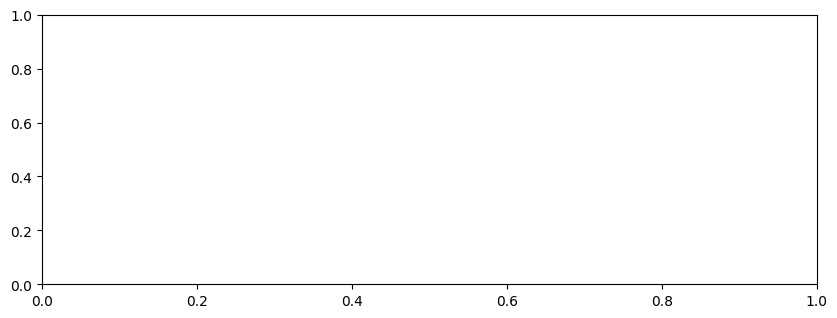

In [44]:

def plot_renewable_availability_series(ava_tensor, renew_gens, T_list=None):
    """
    ava_tensor: torch.Tensor or np.ndarray, shape [N_renew, T]
    renew_gens: list of (loc, tech) length N_renew
    T_list: optional list of timesteps length T (e.g. 1..8760). If None, uses 0..T-1.
    """
    if hasattr(ava_tensor, "detach"):
        A = ava_tensor.detach().cpu().numpy()
    else:
        A = np.asarray(ava_tensor)

    N, T = A.shape
    x = np.array(T_list) if T_list is not None else np.arange(T)
    print(f"Plotting availability for {N} renewable generators over {T} timesteps. x shape: {x.shape}, A shape: {A.shape}")
    for i, (loc, tech) in enumerate(renew_gens):
        y = A[i]
        m = float(y.mean())

        plt.figure(figsize=(10, 3.5))
        plt.plot(x, y, linewidth=1)
        plt.axhline(m, linestyle="--", linewidth=2, label=f"mean = {m:.3f}", color="red")
        plt.title(f"Availability over time — {loc} {tech}")
        plt.xlabel("t")
        plt.ylabel("availability")
        plt.ylim(-0.05, 1.05)
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()

# use it
# T list to be from 1 to 120
T_list = list(range(1, 121))
plot_renewable_availability_series(ava_tensor, renew_gens, T_list)

In [ ]:
for (loc,g) in noconst_data.G:
    cost = noconst_data.pVarCost.get((loc,g), None)
    print(f"Generator {(loc,g)} has variable cost: {cost}")

Generator ('BEL', 'WindOff') has variable cost: 0.005
Generator ('BEL', 'Gas') has variable cost: 0.05
Generator ('GER', 'Gas') has variable cost: 0.05
Generator ('GER', 'SunPV') has variable cost: 0.0001
Generator ('FRA', 'Nuclear') has variable cost: 0.01
Generator ('FRA', 'SunPV') has variable cost: 0.0001


In [45]:
import numpy as np
import torch

def compute_generator_investment_ub(
    data,
    renewable_types=("sunpv", "windon", "windoff"),
    ava_stat="p90",          # "mean", "p90", "max"
    beta=1.05,
    max_inv_cap=None,        # e.g. 1000.0, or None for no global cap
    eps=1e-8,
):
    """
    Returns:
      ub_g: torch.Tensor shape [num_g] with per-generator investment upper bounds u_g^UB
      info: dict with node caps and renewable availability stats (for debugging)
    """

    # 1) node max demand: max_t D_{n,t}
    node_max_demand = {}
    for n in data.N:
        node_max_demand[n] = max(float(data.pDemand[(n, t)]) for t in data.T)

    # 2) node export cap: sum outgoing line export capacities
    node_export_cap = {n: 0.0 for n in data.N}
    for (start_node, end_node) in data.L:
        node_export_cap[start_node] += float(data.pExpCap[(start_node, end_node)])

    # 3) node deliverable cap C_n
    node_cap = {n: node_max_demand[n] + node_export_cap[n] for n in data.N}

    # helper
    def is_renewable(g):
        _, tech = g
        return str(tech).lower() in set(renewable_types)

    def availability_stat(g):
        """Compute A_g^{stat} over time, using pGenAva[(loc, tech, t)]."""
        loc, tech = g
        vals = [float(data.pGenAva.get((loc, tech, t), 1.0)) for t in data.T]
        arr = np.asarray(vals, dtype=float)
        if ava_stat == "mean":
            a = float(arr.mean())
        elif ava_stat == "max":
            a = float(arr.max())
        elif ava_stat == "p90":
            a = float(np.quantile(arr, 0.9))
        elif ava_stat == "constant":
            a = 1.0
        else:
            raise ValueError(f"ava_stat must be one of: mean, p90, max. Got {ava_stat}")
        return max(a, eps)  # avoid division by ~0

    # 4) per-generator ub
    ub = []
    ava_used = {}
    for g in data.G:
        n, _ = g
        pmax = float(data.pUnitCap[g])

        if pmax <= 0:
            u_ub = 0.0
        else:
            Cn = float(node_cap[n])
            if is_renewable(g):
                a = availability_stat(g)
                ava_used[g] = a
                u_ub = beta * Cn / (pmax * a)
            else:
                u_ub = beta * Cn / pmax

        if max_inv_cap is not None:
            u_ub = min(u_ub, float(max_inv_cap))

        ub.append(u_ub)

    ub_g = torch.tensor(ub, dtype=data.DTYPE)

    info = {
        "node_max_demand": node_max_demand,
        "node_export_cap": node_export_cap,
        "node_cap": node_cap,
        "ava_used_for_renewables": ava_used,  # only populated for renewables
    }
    return ub_g, info

In [46]:
ub_g, info = compute_generator_investment_ub(noconst_data, ava_stat = "constant")


for g, ub in zip(noconst_data.G, ub_g.tolist()):
    print(g, "Max Bound in investment generation =", round(ub,2))



('BEL', 'WindOff') Max Bound in investment generation = 147.74
('BEL', 'Gas') Max Bound in investment generation = 59.09
('GER', 'Gas') Max Bound in investment generation = 303.5
('GER', 'SunPV') Max Bound in investment generation = 1517.52
('FRA', 'Nuclear') Max Bound in investment generation = 75.53
('FRA', 'SunPV') Max Bound in investment generation = 1510.56


In [47]:
ub_g, info = compute_generator_investment_ub(noconst_data, ava_stat = "mean")


for g, ub in zip(noconst_data.G, ub_g.tolist()):
    print(g, "u_ub =", ub)

('BEL', 'WindOff') u_ub = 273.3182010531157
('BEL', 'Gas') u_ub = 59.09447769762243
('GER', 'Gas') u_ub = 303.50453688885875
('GER', 'SunPV') u_ub = 12375.796293202193
('FRA', 'Nuclear') u_ub = 75.52820713208159
('FRA', 'SunPV') u_ub = 10333.249170524188


In [48]:
ub_g, info = compute_generator_investment_ub(noconst_data, ava_stat = "p90")


for g, ub in zip(noconst_data.G, ub_g.tolist()):
    print(g, "u_ub =", ub)

('BEL', 'WindOff') u_ub = 165.43806746254882
('BEL', 'Gas') u_ub = 59.09447769762243
('GER', 'Gas') u_ub = 303.50453688885875
('GER', 'SunPV') u_ub = 3613.1492486768902
('FRA', 'Nuclear') u_ub = 75.52820713208159
('FRA', 'SunPV') u_ub = 3180.1350371402773


In [49]:
const_data.pUnitInvestment

tensor([[668.9105,  33.8406, 167.4132, 372.1064,  18.7657, 165.4366],
        [211.9314,  21.6104,   2.5259, 401.9398,  22.3802, 454.2009],
        [431.6273,  26.9796, 134.3524, 569.5231,  73.9105, 688.2883],
        ...,
        [ 49.3668,  39.0334, 222.4614, 174.2199,  11.2026, 451.0125],
        [483.4451,   1.2003, 276.9252,  50.3157,  19.9426, 546.5724],
        [906.6238,   6.8074,  59.9215, 980.7160,  31.7358, 228.3080]],
       dtype=torch.float64)

# Check whether the data generation is correct!

In [50]:
def gen_data_summary(data_path, data_name):
    print(f" ==== Summary for {data_name} ====")
    data = pickle.load(open(data_path, 'rb'))
    print(f"Number of locations (N): {len(data.N)}")
    print(f"Number of generators (G): {len(data.G)}")
    print(f"Number of transmission lines (L): {len(data.L)}")

    Y = data.opt_targets['y_operational']
    X = data.X

    prod_cost, unmet_cost, obj = obj_compute(data, X, Y)


    percentage_unmet = (unmet_cost / obj) * 100
    print(f"For the Constraint Dataset")
    print("Mean % unmet:", percentage_unmet.mean().item())
    print("Median % unmet:", percentage_unmet.median().item())
    print("P90 % unmet:", percentage_unmet.quantile(0.9).item())
    print(percentage_unmet)

    print(f"Max investment {data.pUnitInvestment.max(dim = 0)[0]}")

In [51]:
gen_data_summary("data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl", "3Node Renewable renew10000")

 ==== Summary for 3Node Renewable renew10000 ====


FileNotFoundError: [Errno 2] No such file or directory: 'data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl'

In [52]:
gen_data_summary("data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc50.pkl", "3Node Renewable 50% Constraint")

 ==== Summary for 3Node Renewable 50% Constraint ====


FileNotFoundError: [Errno 2] No such file or directory: 'data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc50.pkl'

In [53]:
gen_data_summary("data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc90.pkl","3Node Renew 90% Constraint")

 ==== Summary for 3Node Renew 90% Constraint ====


FileNotFoundError: [Errno 2] No such file or directory: 'data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc90.pkl'

In [54]:
const_LB_data_path = "data/ED_data/Constraint/4Node/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl"
gen_data_summary(const_LB_data_path, "4Node")

 ==== Summary for 4Node ====


FileNotFoundError: [Errno 2] No such file or directory: 'data/ED_data/Constraint/4Node/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl'

In [55]:
"""
Dataset Comparison Utility
==========================
Produces a structured summary DataFrame and thesis-quality comparison plots
for multiple ED datasets (D0–D3).

Usage:
    from dataset_comparison import compare_datasets, plot_comparison

    # Define your datasets as {name: path} dict
    datasets = {
        "D0 (Baseline)":        "data/ED_data/.../D0.pkl",
        "D1 (Constrained NR)":  "data/ED_data/.../D1.pkl",
        "D2 (Renew 10k)":       "data/ED_data/.../D2.pkl",
        "D3 (Renew 50pct)":     "data/ED_data/.../D3.pkl",
    }

    summary_df, details = compare_datasets(datasets)
    print(summary_df.to_latex())          # paste straight into thesis
    plot_comparison(summary_df, details)   # saves figure
"""

import pickle
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path


# ── 1. Single-dataset statistics ────────────────────────────────────────────

def dataset_stats(data, obj_compute_fn):
    """Return a dict of scalar statistics + per-sample tensors for one dataset."""
    Y = data.opt_targets["y_operational"]
    X = data.X

    prod_cost, unmet_cost, obj = obj_compute_fn(data, X, Y)
    pct_unmet = (unmet_cost / obj) * 100

    max_inv = data.pUnitInvestment.max(dim=0)[0]  # per-generator max

    return {
        # Scalars  →  go into the summary table
        "N (locations)":        len(data.N),
        "G (generators)":       len(data.G),
        "L (lines)":            len(data.L),
        "Samples":              X.shape[0],
        "Mean % unmet":         pct_unmet.mean().item(),
        "Median % unmet":       pct_unmet.median().item(),
        "P90 % unmet":          pct_unmet.quantile(0.9).item(),
        "Max % unmet":          pct_unmet.max().item(),
        "Mean obj":             obj.mean().item(),
        # Vectors  →  kept for plots
        "_pct_unmet":           pct_unmet,
        "_max_inv":             max_inv,
        "_investment":          X,          # full investment matrix
    }


# ── 2. Multi-dataset comparison ─────────────────────────────────────────────

def compare_datasets(dataset_dict, obj_compute_fn):
    """
    Parameters
    ----------
    dataset_dict : dict[str, str]
        Mapping from display name → pickle file path.
    obj_compute_fn : callable
        Your existing `obj_compute(data, X, Y)` function.

    Returns
    -------
    summary_df : pd.DataFrame
        One row per dataset, columns are the scalar statistics.
    details : dict[str, dict]
        Full per-dataset details including tensors (for plotting).
    """
    rows = {}
    details = {}
    for name, path in dataset_dict.items():
        data = pickle.load(open(path, "rb"))
        stats = dataset_stats(data, obj_compute_fn)
        # Separate scalars from tensors
        rows[name] = {k: v for k, v in stats.items() if not k.startswith("_")}
        details[name] = stats

    summary_df = pd.DataFrame(rows).T
    summary_df.index.name = "Dataset"

    # Round for readability
    float_cols = summary_df.select_dtypes(include="float").columns
    summary_df[float_cols] = summary_df[float_cols].round(2)

    return summary_df, details


# ── 3. Comparison plots ─────────────────────────────────────────────────────

def plot_comparison(summary_df, details, save_path="dataset_comparison.pdf"):
    """
    Produces a 1×3 figure:
      (a) Bar chart of Mean / Median / P90 % unmet across datasets
      (b) Box plot of % unmet distributions
      (c) Grouped bar chart of per-generator max investment
    """
    names = list(details.keys())
    n = len(names)
    colors = plt.cm.Set2(np.linspace(0, 1, max(n, 3)))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    # ── (a) Summary bar chart ───────────────────────────────────────────────
    ax = axes[0]
    metrics = ["Mean % unmet", "Median % unmet", "P90 % unmet"]
    x = np.arange(len(metrics))
    width = 0.8 / n
    for i, name in enumerate(names):
        vals = [summary_df.loc[name, m] for m in metrics]
        ax.bar(x + i * width, vals, width, label=name, color=colors[i])
    ax.set_xticks(x + width * (n - 1) / 2)
    ax.set_xticklabels(["Mean", "Median", "P90"], fontsize=10)
    ax.set_ylabel("% Unmet demand", fontsize=11)
    ax.set_title("(a) Unmet demand statistics", fontsize=12)
    ax.legend(fontsize=8, loc="upper left")

    # ── (b) Box plot of % unmet distributions ───────────────────────────────
    ax = axes[1]
    box_data = []
    for name in names:
        t = details[name]["_pct_unmet"]
        box_data.append(t.numpy() if isinstance(t, torch.Tensor) else np.array(t))
    bp = ax.boxplot(box_data, labels=[n.split("(")[0].strip() for n in names],
                    patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
    ax.set_ylabel("% Unmet demand", fontsize=11)
    ax.set_title("(b) Distribution of % unmet", fontsize=12)

    # ── (c) Per-generator max investment ────────────────────────────────────
    ax = axes[2]
    # Assume generator count is same across datasets
    first = details[names[0]]["_max_inv"]
    G = len(first)
    gen_labels = [f"G{i}" for i in range(G)]
    x = np.arange(G)
    width = 0.8 / n
    for i, name in enumerate(names):
        inv = details[name]["_max_inv"]
        vals = inv.numpy() if isinstance(inv, torch.Tensor) else np.array(inv)
        ax.bar(x + i * width, vals, width, label=name, color=colors[i])
    ax.set_xticks(x + width * (n - 1) / 2)
    ax.set_xticklabels(gen_labels, fontsize=10)
    ax.set_ylabel("Max investment", fontsize=11)
    ax.set_title("(c) Max investment per generator", fontsize=12)
    ax.legend(fontsize=8, loc="upper left")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Figure saved → {save_path}")
    plt.show()


# ── 4. LaTeX table export helper ────────────────────────────────────────────

def to_latex_table(summary_df, caption="Dataset comparison summary.",
                   label="tab:dataset-comparison"):
    """Return a LaTeX string ready for \\input{} in your thesis."""
    cols = ["N (locations)", "G (generators)", "Samples",
            "Mean % unmet", "Median % unmet", "P90 % unmet"]
    cols = [c for c in cols if c in summary_df.columns]

    latex = summary_df[cols].to_latex(
        float_format="%.2f",
        caption=caption,
        label=label,
        column_format="l" + "r" * len(cols),
        bold_rows=True,
    )
    return latex



In [56]:
def plot_max_investment(details, gen_names=None,
                        save_path=None, chart_title="Max investment per generator across datasets"):
    """
    Standalone figure: grouped bar chart of per-generator max investment.
 
    Parameters
    ----------
    details : dict
        The `details` dict returned by `compare_datasets()`.
    gen_names : list[str], optional
        Generator names for the x-axis, e.g.
        ["BEL-WindOff", "BEL-Gas", "GER-Gas", "GER-SunPV", "FRA-Nuclear", "FRA-SunPV"].
        If None, tries to read them from the data; falls back to G0, G1, ...
    save_path : str
        Output path for the figure.
    """
    names = list(details.keys())
    n = len(names)
    colors = plt.cm.Set2(np.linspace(0, 1, max(n, 3)))
 
    first_detail = details[names[0]]
    G = len(first_detail["_max_inv"])
 
    # Resolve generator labels: explicit arg > stored in data > fallback
    if gen_names is None:
        gen_names = first_detail.get("_gen_names")
    if gen_names is None:
        gen_names = [f"G{i}" for i in range(G)]
 
    x = np.arange(G)
    width = 0.8 / n
 
    fig, ax = plt.subplots(figsize=(max(8, G * 1.6), 5), constrained_layout=True)
 
    for i, name in enumerate(names):
        inv = details[name]["_max_inv"]
        vals = inv.numpy() if isinstance(inv, torch.Tensor) else np.array(inv)
        ax.bar(x + i * width, vals, width, label=name, color=colors[i])
 
    ax.set_xticks(x + width * (n - 1) / 2)
    ax.set_xticklabels(gen_names, fontsize=10, rotation=30, ha="right")
    ax.set_xlabel("Generator", fontsize=11)
    ax.set_ylabel("Max investment", fontsize=11)
    ax.set_title(chart_title, fontsize=13)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="y", alpha=0.3)
 
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved → {save_path}")
    plt.show()
 

In [57]:
datasets = {
    "D0 (Baseline)":       "data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl",
    "D1 ": "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl",
    "D2 ":      "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl",
    "D3 ":    "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc50.pkl",
    "D4": "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc90.pkl",
}

summary_df, details = compare_datasets(datasets, obj_compute)

# print(to_latex_table(summary_df))
plot_comparison(summary_df, details, save_path="figures/dataset_comparison.pdf")

FileNotFoundError: [Errno 2] No such file or directory: 'data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl'

In [58]:
    plot_max_investment(
        details,
        gen_names=["BEL-WindOff", "BEL-Gas", "GER-Gas",
                   "GER-SunPV", "FRA-Nuclear", "FRA-SunPV"],
        save_path="figures/max_investment.pdf",
        chart_title="Max investment per generator across datasets for 3 Location case"
    )

NameError: name 'details' is not defined

In [59]:
summary_df

NameError: name 'summary_df' is not defined

### 4Node

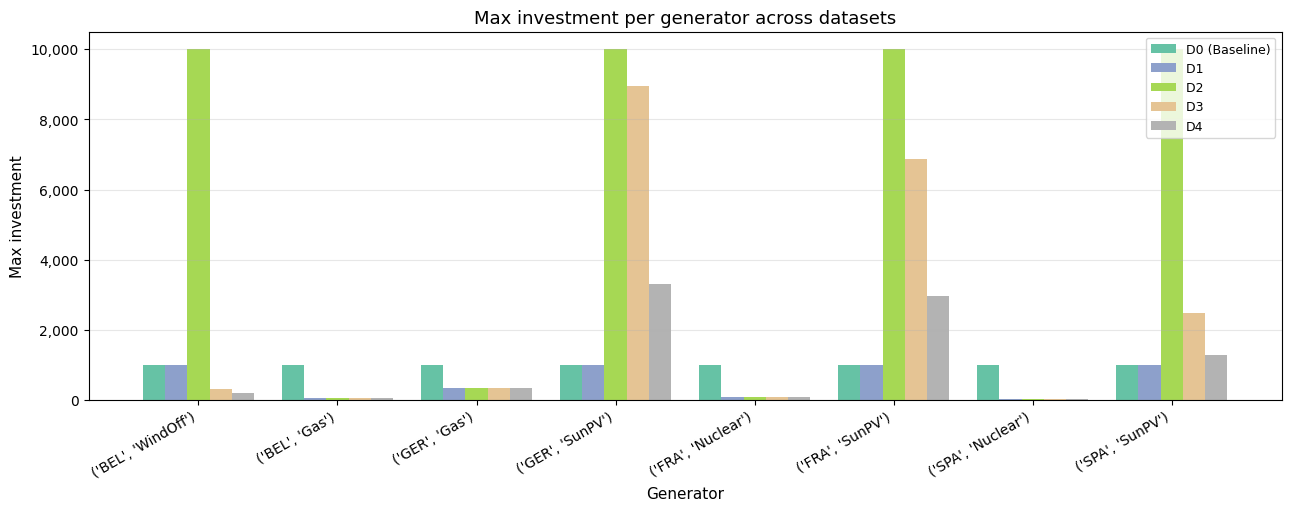

In [60]:


datasets = {
    "D0 (Baseline)":       "data/ED_data/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_smp15.pkl",
    "D1 ": "data/ED_data/Constraint/4Loc/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl",
    "D2 ":      "data/ED_data/Constraint/4Loc/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl",
    "D3 ":    "data/ED_data/Constraint/4Loc/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc50.pkl",
    "D4": "data/ED_data/Constraint/4Loc/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc90.pkl",
}

summary_df, details = compare_datasets(datasets, obj_compute)

# print(to_latex_table(summary_df))
# plot_comparison(summary_df, details, save_path="figures/dataset_comparison.pdf")
data_4Node = pickle.load(open(datasets["D0 (Baseline)"], 'rb'))
# print(data_4Node.G)

plot_max_investment(
    details,
    gen_names=data_4Node.G,
    # save_path="figures/max_investment.pdf",
)

## Plot Availablity

In [61]:
import pickle
import numpy as np
import matplotlib.pyplot as plt


baseline_data_path = "data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
baseline_data = pickle.load(open(baseline_data_path, "rb"))

T = range(1, 168)

renewable_gens = [g for g in baseline_data.G if g[1].lower() in ["windoff", "sunpv", "windon"]]

ava_matrix = np.array([
    [baseline_data.pGenAva.get((*g, t), 1.0) for t in T]
    for g in renewable_gens
])

print(renewable_gens)
# [('BEL', 'WindOff'), ('GER', 'SunPV'), ('FRA', 'SunPV')]
print(ava_matrix.shape)
# (3, 119)

[('BEL', 'WindOff'), ('GER', 'SunPV'), ('FRA', 'SunPV')]
(3, 167)


In [62]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


def add_icon(ax, image_path, xy, zoom=0.12):
    img = mpimg.imread(image_path)
    ab = AnnotationBbox(
        OffsetImage(img, zoom=zoom),
        xy,
        frameon=False,
        xycoords="data",
        box_alignment=(0.5, 0.5),
        zorder=5,
    )
    ax.add_artist(ab)


def plot_availability_with_icons(
    renewable_gens,
    ava_matrix,
    hours=None,
    wind_idx=None,
    solar_idx=None,
    wind_icon_path="icons/wind-turbine.png",
    solar_icon_path="icons/sun.png",
    save_path=None,
):
    if hours is None:
        hours = np.arange(ava_matrix.shape[1])

    if wind_idx is None:
        wind_idx = next(i for i, g in enumerate(renewable_gens) if "wind" in g[1].lower())
    if solar_idx is None:
        solar_idx = next(i for i, g in enumerate(renewable_gens) if "sun" in g[1].lower())

    wind_y = ava_matrix[wind_idx]
    solar_y = ava_matrix[solar_idx]

    fig, ax = plt.subplots(figsize=(11, 3.8))

    # plot lines
    ax.plot(hours, wind_y, linewidth=2.0, label=f"{renewable_gens[wind_idx][0]} {renewable_gens[wind_idx][1]}")
    ax.plot(hours, solar_y, linewidth=2.0, label=f"{renewable_gens[solar_idx][0]} {renewable_gens[solar_idx][1]}", color="red")

    # axis styling
    ax.set_title("Renewable Generator Availability", fontsize=18)
    ax.set_xlabel("Hour", fontsize=16)
    ax.set_ylabel("Available capacity (%)", fontsize=16)
    ax.set_ylim(-0.05, 1.02)
    ax.grid(True, alpha=0.25)

    # add icons near left side
    x_icon = hours[0]
    add_icon(ax, wind_icon_path, (x_icon, 0.84), zoom=0.12)
    add_icon(ax, solar_icon_path, (x_icon, 0.12), zoom=0.13)

    # cleaner frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=False)

    plt.show()

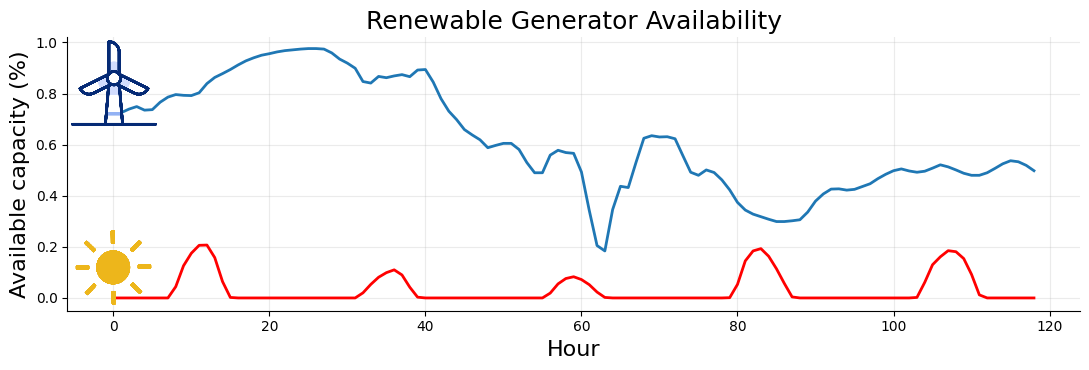

In [63]:
baseline_data_path = "data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
baseline_data = pickle.load(open(baseline_data_path, "rb"))

T = range(1, 120)

renewable_gens = [g for g in baseline_data.G if g[1].lower() in ["windoff", "sunpv", "windon"]]

ava_matrix = np.array([
    [baseline_data.pGenAva.get((*g, t), 1.0) for t in T]
    for g in renewable_gens
])

plot_availability_with_icons(
    renewable_gens,
    ava_matrix,
    hours=np.arange(len(list(T))),
    wind_icon_path="icons/wind-turbine.png",
    solar_icon_path="icons/sun.png",
    save_path="availability_with_icons.png",
)

In [64]:
T = range(1, 120)

ned_demand = np.array([baseline_data.pDemand[("NED", t)] for t in T])
ger_demand = np.array([baseline_data.pDemand[("GER", t)] for t in T])

print("NED demand:", ned_demand.shape)
print("GER demand:", ger_demand.shape)

NED demand: (119,)
GER demand: (119,)


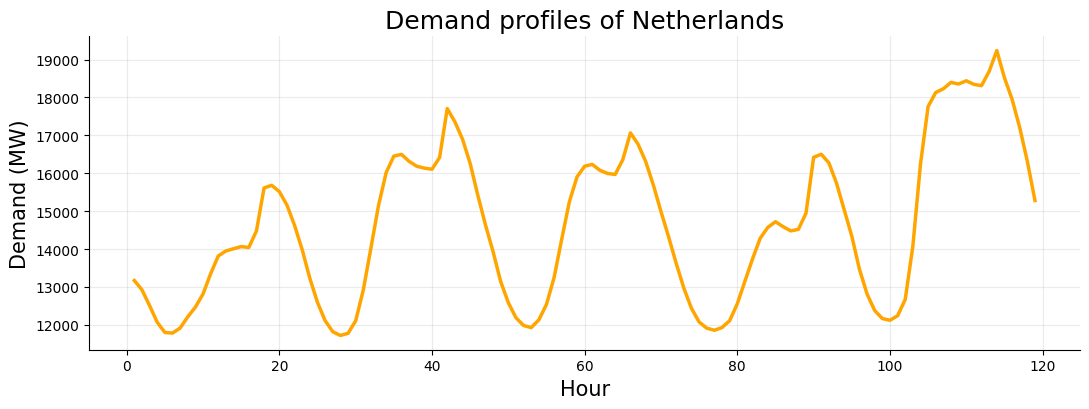

In [65]:
import matplotlib.pyplot as plt
import numpy as np

hours = np.arange(1, 120)

fig, ax = plt.subplots(figsize=(11, 4.2))

ax.plot(hours, ned_demand, linewidth=2.5, label="NED", color = "orange")
# ax.plot(hours, ger_demand, linewidth=2.5, label="GER")

ax.set_title("Demand profiles of Netherlands", fontsize=18)
ax.set_xlabel("Hour", fontsize=15)
ax.set_ylabel("Demand (MW)", fontsize=15)
ax.grid(True, alpha=0.25)
# ax.legend(frameon=False, fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

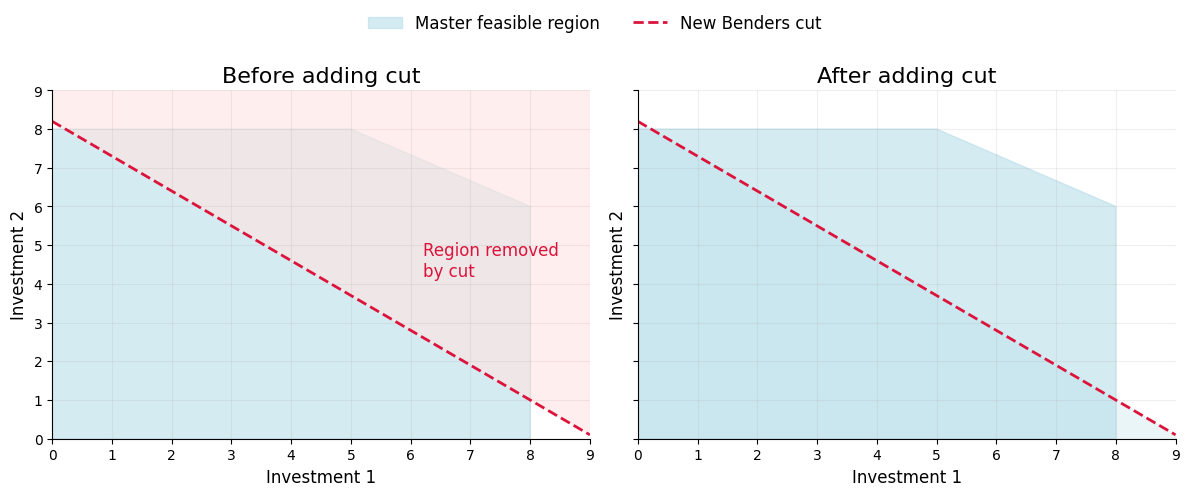

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Feasible region polygon
# -----------------------------
# Simple master feasible set in 2D
poly = np.array([
    [0, 0],
    [8, 0],
    [8, 6],
    [5, 8],
    [0, 8]
])

# Benders cut: a*x + b*y <= c
a, b, c = 0.9, 1.0, 8.2

# grid for shading
x = np.linspace(0, 9, 400)
y = np.linspace(0, 9, 400)
X, Y = np.meshgrid(x, y)
cut_val = a * X + b * Y
cut_line_y = (c - a * x) / b

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

titles = ["Before adding cut", "After adding cut"]

for i, ax in enumerate(axes):
    # feasible region
    ax.fill(poly[:, 0], poly[:, 1], color="lightblue", alpha=0.5, label="Master feasible region")

    # cut line
    ax.plot(x, cut_line_y, "--", linewidth=2, color="crimson", label="New Benders cut")

    # shaded removed region only in first plot
    if i == 0:
        ax.contourf(
            X, Y, cut_val,
            levels=[c, cut_val.max()],
            colors=["mistyrose"],
            alpha=0.6
        )
        ax.text(6.2, 4.2, "Region removed\nby cut", color="crimson", fontsize=12)
    else:
        # keep only the side satisfying the cut
        ax.contourf(
            X, Y, cut_val,
            levels=[cut_val.min(), c],
            colors=["lightblue"],
            alpha=0.25
        )

    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_xlabel("Investment 1", fontsize=12)
    ax.set_ylabel("Investment 2", fontsize=12)
    ax.set_title(titles[i], fontsize=16)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# legend only once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

## Capacity Sampling, Check Bound

In [67]:
import pickle
''' 
const_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl" # COnstrainted
orig_data_path = "data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
node_const_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewPerc90_NodeConst.pkl"
cap_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_CapSobol_GenConst_ui_constraint1000_smp15_renewMaxInvTrue_NodeConst.pkl"
'''
data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl"
data = pickle.load(open(data_path, "rb"))
print("Locations:", data.N)
print("Generators:", data.G)
print("Lines:", data.L)

Locations: ['BEL', 'GER', 'FRA']
Generators: [('BEL', 'WindOff'), ('BEL', 'Gas'), ('GER', 'Gas'), ('GER', 'SunPV'), ('FRA', 'Nuclear'), ('FRA', 'SunPV')]
Lines: [('BEL', 'GER'), ('BEL', 'FRA'), ('GER', 'FRA')]


In [68]:
for l in data.L:
    print(f"Line: {l}: outCap = {data.pExpCap[l]} inCap = {data.pImpCap[l]}")

Line: ('BEL', 'GER'): outCap = 2380 inCap = 2000
Line: ('BEL', 'FRA'): outCap = 2800 inCap = 4300
Line: ('GER', 'FRA'): outCap = 4800 inCap = 5180


In [69]:
import pandas as pd
import numpy as np
import torch

def compute_effective_capacity_bounds(data, beta=None):
    """
    Computes the bound:

        u_g * A_g <= (max_t D_{n,t} + sum_out F_l) / P_g^max

    and the equivalent ED capacity bound:

        u_g * A_g * P_g^max <= max_t D_{n,t} + sum_out F_l

    For generate_capacity_sobol=True, the sampled capacity variables correspond
    directly to the ED capacity upper bounds.
    """
    if beta is None:
        beta = data.ED_args.get("gen_data_beta", 1.0)

    max_inv = float(data.ED_args["max_investment"])

    # max_t D_{n,t}
    node_max_demand = {
        n: max(float(data.pDemand[(n, t)]) for t in data.T)
        for n in data.N
    }

    # sum_{l in L_n^out} F_l
    # This matches your written equation using outgoing export capacity only.
    node_out_cap = {n: 0.0 for n in data.N}

    for l in data.L:
        start_node, end_node = l
        node_out_cap[start_node] += float(data.pExpCap[l])
        node_out_cap[end_node] += float(data.pImpCap[l]) 

    rows = []
    for g_idx, g in enumerate(data.G):
        n, tech = g
        pmax = float(data.pUnitCap[g])

        rhs_capacity = beta * (node_max_demand[n] + node_out_cap[n])

        effective_investment_ub = rhs_capacity / pmax
        hard_effective_investment_ub = max_inv

        final_effective_investment_ub = min(
            effective_investment_ub,
            hard_effective_investment_ub
        )

        effective_capacity_ub = final_effective_investment_ub * pmax

        rows.append({
            "generator": g,
            "node": n,
            "tech": tech,
            "Pmax_g": pmax,
            "max_demand_node": node_max_demand[n],
            "outgoing_capacity_node": node_out_cap[n],
            "beta": beta,
            "effective_investment_ub_u_times_A": effective_investment_ub,
            "hard_ub_max_investment": hard_effective_investment_ub,
            "final_effective_investment_ub": final_effective_investment_ub,
            "effective_capacity_ub": effective_capacity_ub,
        })

    return pd.DataFrame(rows)

df_eff_bound = compute_effective_capacity_bounds(data)
df_eff_bound
# print(data.X[0,:])
print(data.X[:,-6:].max(dim = 0).values)
print(data.pUnitInvestment.max(dim = 0)[0])

tensor([98599.1032, 14773.2170, 75873.9514, 39582.8735, 75527.3048, 39890.7031],
       dtype=torch.float64)
tensor([999.9949,  59.0929, 303.4958, 999.9780,  75.5273, 999.9828],
       dtype=torch.float64)


In [70]:
cap_sample_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_CapSobol_GenConst_ui_constraint1000_smp15_renewMaxInvTrue_NodeConst.pkl"
cap_sample_data = pickle.load(open(cap_sample_data_path, "rb"))

df_eff_bound = compute_effective_capacity_bounds(cap_sample_data)
df_eff_bound

print(cap_sample_data.X[:,-6:].max(dim = 0).values)

tensor([16883.7128, 16884.0426, 89114.1657, 49999.2604, 97691.2695, 49998.7627],
       dtype=torch.float64)


## Plot Ground Truth Lambda Distribution

In [71]:
import os
import numpy as np
import matplotlib.pyplot as plt
from networks import DualClassificationNetEndToEnd
import json
import pickle

def plot_lambda_true_dist(
    data,
    dual_net,
    title=r"True $\lambda$-class distribution on the test set",
    use_title=True,
    save_name="lambda_true_class_distribution.png",
    panel_width=7.2,
    panel_height=6.2,
    dpi=600,
    return_distribution=False,
):
    """
    Plot only the ground-truth lambda-class distribution per node/location.

    Args:
        data:
            Dataset object containing data.num_n and data.N.
        dual_net:
            Dual model containing dual_net.classes.
        title:
            Figure title.
        use_title:
            Whether to show title and top legend.
        save_name:
            Name of the saved figure file.
        panel_width:
            Width of each node subplot.
        panel_height:
            Height of the figure.
        dpi:
            Resolution for saved figure.
        return_distribution:
            If True, returns per-node class proportions.

    Returns:
        Optional list of dictionaries containing class proportions per node.
    """
    lamb_true = data.opt_targets["lamb_operational"]
    lamb_true_np = (
        lamb_true.detach().cpu().numpy()
        if hasattr(lamb_true, "detach")
        else np.asarray(lamb_true)
    )

    class_values = (
        dual_net.classes.detach().cpu().numpy()
        if hasattr(dual_net.classes, "detach")
        else np.asarray(dual_net.classes)
    )

    class_labels = [f"{v:.4f}" for v in class_values]

    num_nodes = data.num_n
    x = np.arange(len(class_values))

    fig, axes = plt.subplots(
        1,
        num_nodes,
        figsize=(panel_width * num_nodes, panel_height),
        sharey=True
    )

    if num_nodes == 1:
        axes = [axes]

    distributions = []

    for node_idx, ax in enumerate(axes):
        node_name = data.N[node_idx]

        true_vals = lamb_true_np[:, node_idx]

        # Map lambda values to nearest class index
        true_idx = np.argmin(
            np.abs(true_vals[:, None] - class_values[None, :]),
            axis=1
        )

        true_counts = np.bincount(
            true_idx,
            minlength=len(class_values)
        ).astype(float)

        true_props = true_counts / max(true_counts.sum(), 1.0)

        distributions.append({
            "node": node_name,
            "class_values": class_values.copy(),
            "class_labels": class_labels.copy(),
            "counts": true_counts.copy(),
            "proportions": true_props.copy(),
        })


        bars = ax.bar(x, true_props, width=0.55, alpha=0.9, label="True")

        for bar, prop in zip(bars, true_props):
            if prop > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.015,
                    f"{prop * 100:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold",
                    rotation=0
                )

        ax.set_title(
            f"{node_name}",
            fontsize=17,
            pad=12,
            fontweight="bold"
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            class_labels,
            rotation=35,
            ha="right",
            fontsize=15,
            fontweight="bold"
        )

        ax.tick_params(axis="y", labelsize=15)

        for label in ax.get_xticklabels():
            label.set_fontweight("bold")
        for label in ax.get_yticklabels():
            label.set_fontweight("bold")

        if node_idx == 0:
            ax.set_ylabel("Proportion", fontsize=19, fontweight="bold")

        ax.set_xlabel(r"$\lambda$ class", fontsize=19, fontweight="bold")
        ax.set_ylim(0, 1.05)

    handles, labels = axes[0].get_legend_handles_labels()

    if use_title:
        fig.suptitle(title, fontsize=23, y=0.98)
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=1,
            frameon=False,
            bbox_to_anchor=(0.5, 0.93),
            fontsize=18
        )
        plt.tight_layout(rect=[0, 0, 1, 0.84])
    else:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=1,
            frameon=False,
            bbox_to_anchor=(0.5, 0.98),
            fontsize=16
        )
        plt.tight_layout(rect=[0, 0, 1, 0.90])

    save_dir = "figures"
    os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(save_dir, save_name)
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0.03)
    plt.show()

    if return_distribution:
        return distributions
    

def load_dual_net(base_path, exp_path, data):
    json_path = os.path.join(base_path, exp_path, "args.json")
    dual_path = os.path.join(base_path, exp_path, "repeat:0", "dual_weights.pth")

    args = json.load(open(json_path))
    if args["dual_classification"]:
        dual_net = DualClassificationNetEndToEnd(args, data=data)
    else:
        dual_net = DualNetEndToEnd(args, data=data)
    dual_net.load_state_dict(
        torch.load(dual_path, weights_only=True),
        strict=False
    )
    dual_net.eval()
    return dual_net,dual_path, json_path

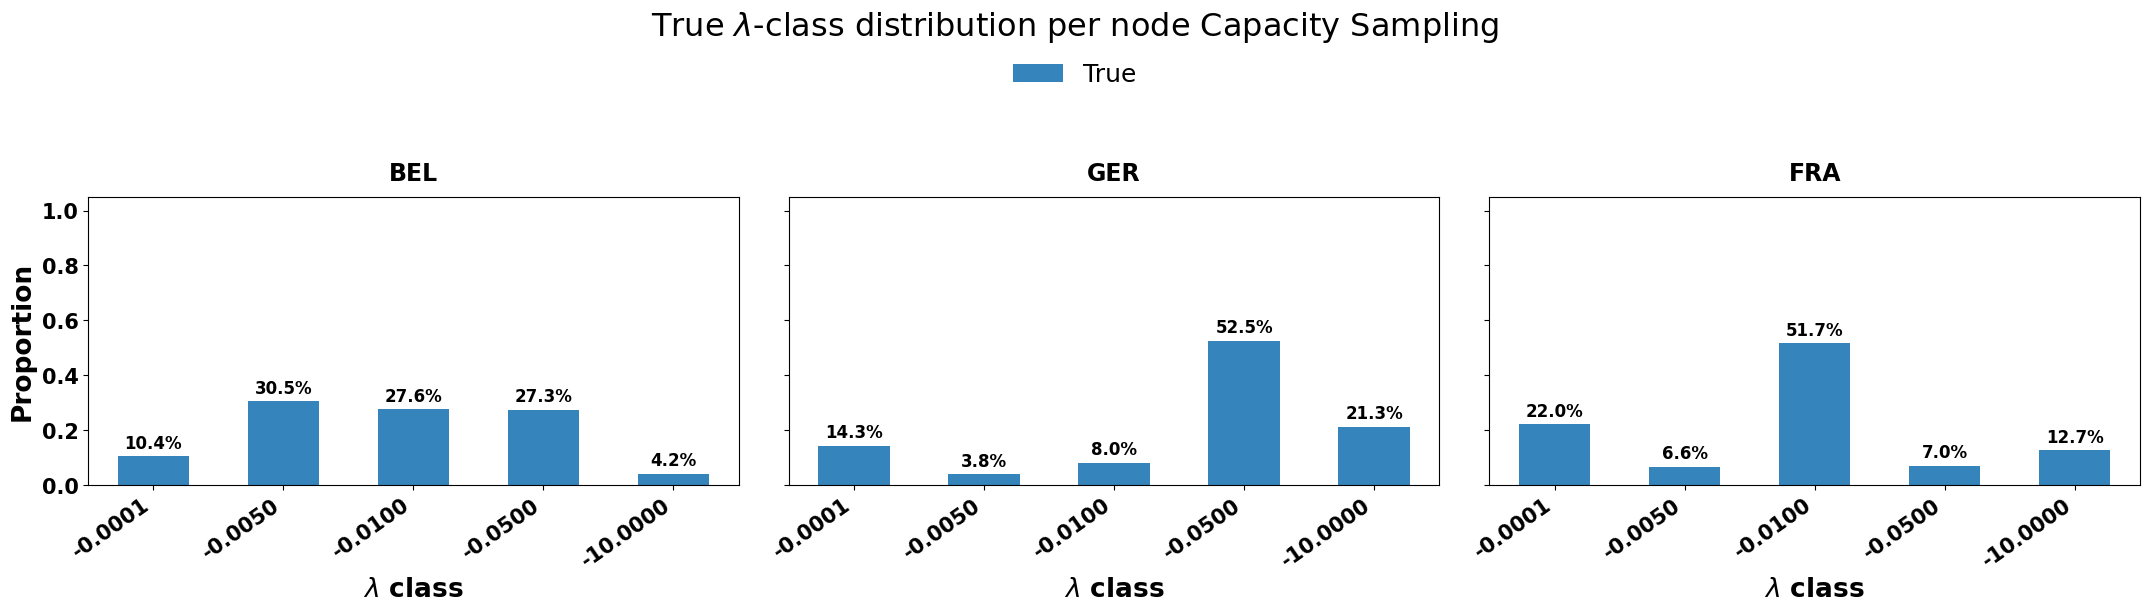

In [75]:
base_path = "outputs/PDL/ED/3Nodes-FraBelGer"
exp_D_1_path = "Constraint/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BaselineConst2"

dual_net, _,_ = load_dual_net(base_path, exp_D_1_path, data)

data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_CapSobol_GenConst_ui_constraint1000_smp15_renewMaxInvTrue.pkl"
data = pickle.load(open(data_path, "rb"))

plot_lambda_true_dist(
    data=data,
    dual_net=dual_net,
    title=r"True $\lambda$-class distribution per node Capacity Sampling",
    save_name="true_lambda_distribution.png"
)

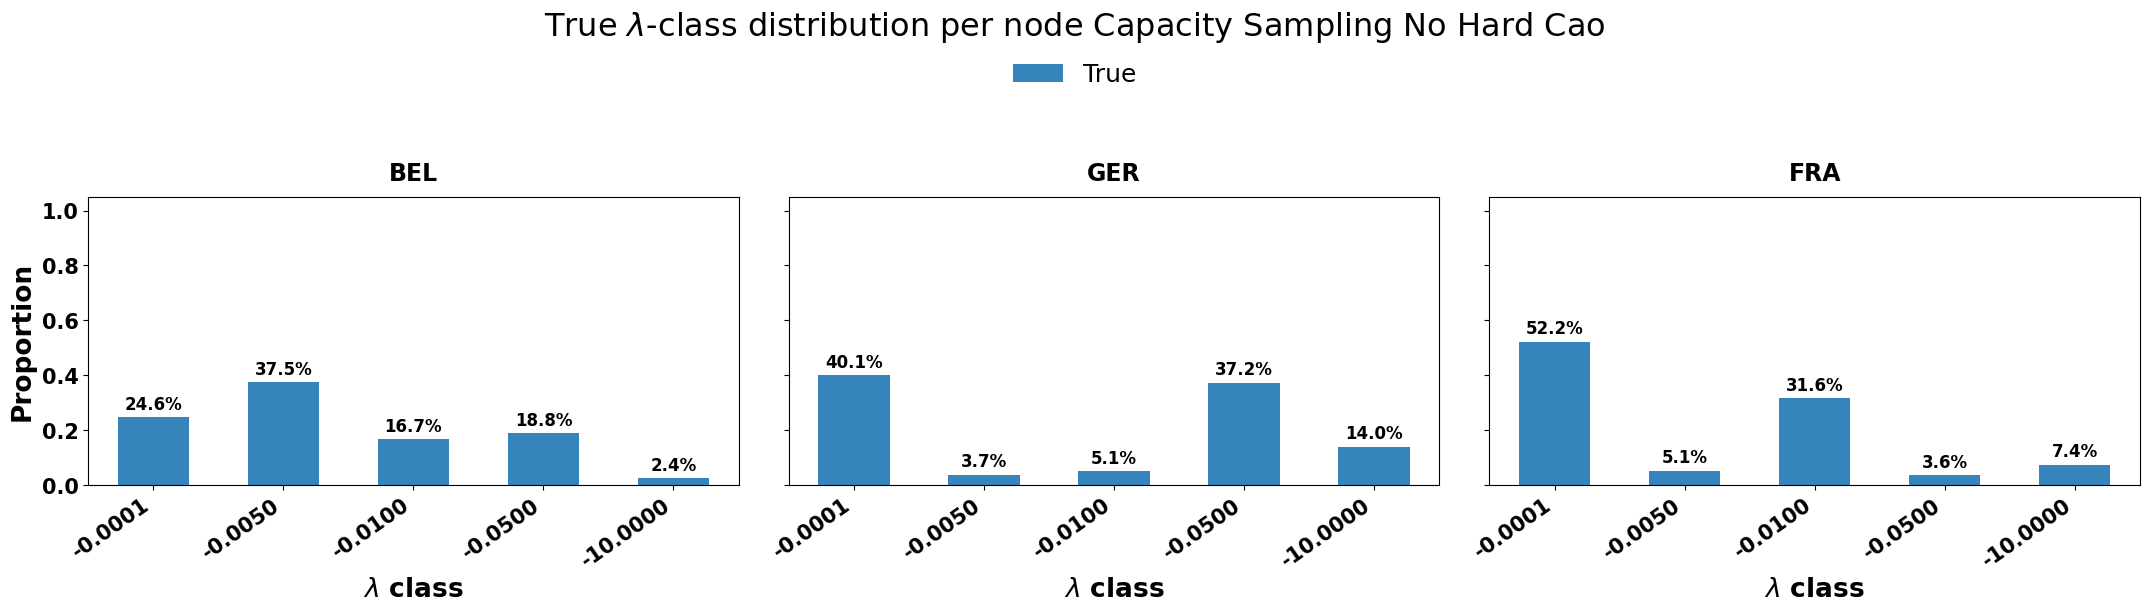

In [73]:
data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_CapSobolNoHardCap_GenConst_ui_constraint1000_smp15_renewMaxInvTrue.pkl"
data = pickle.load(open(data_path, "rb"))

plot_lambda_true_dist(
    data=data,
    dual_net=dual_net,
    title=r"True $\lambda$-class distribution per node Capacity Sampling No Hard Cao",
    save_name="true_lambda_distribution.png"
)

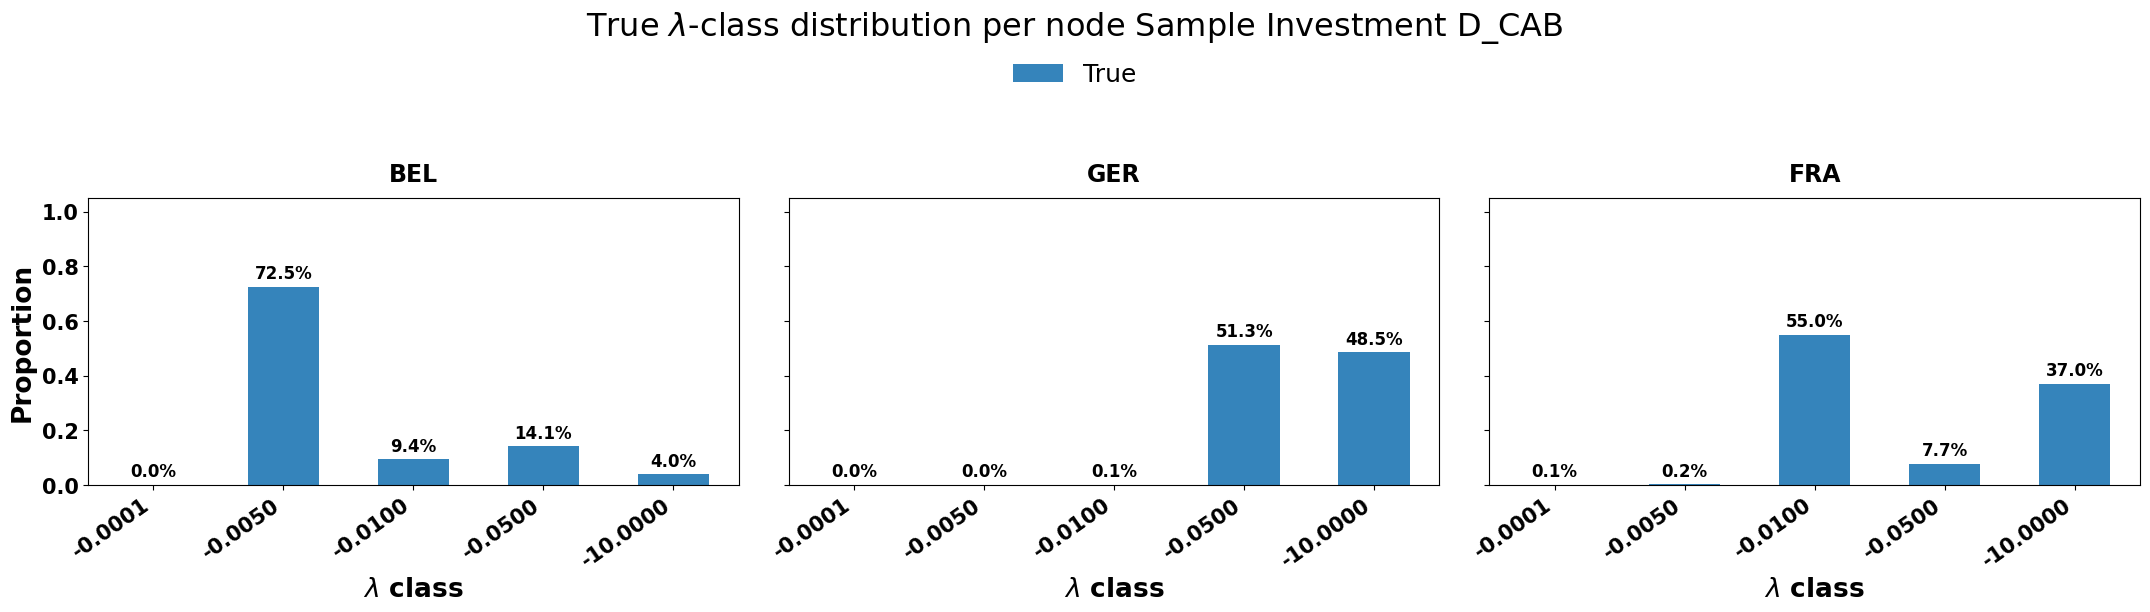

In [9]:
data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl"
data = pickle.load(open(data_path, "rb"))

plot_lambda_true_dist(
    data=data,
    dual_net=dual_net,
    title=r"True $\lambda$-class distribution per node Sample Investment D_CAB",
    save_name="true_lambda_distribution.png"
)

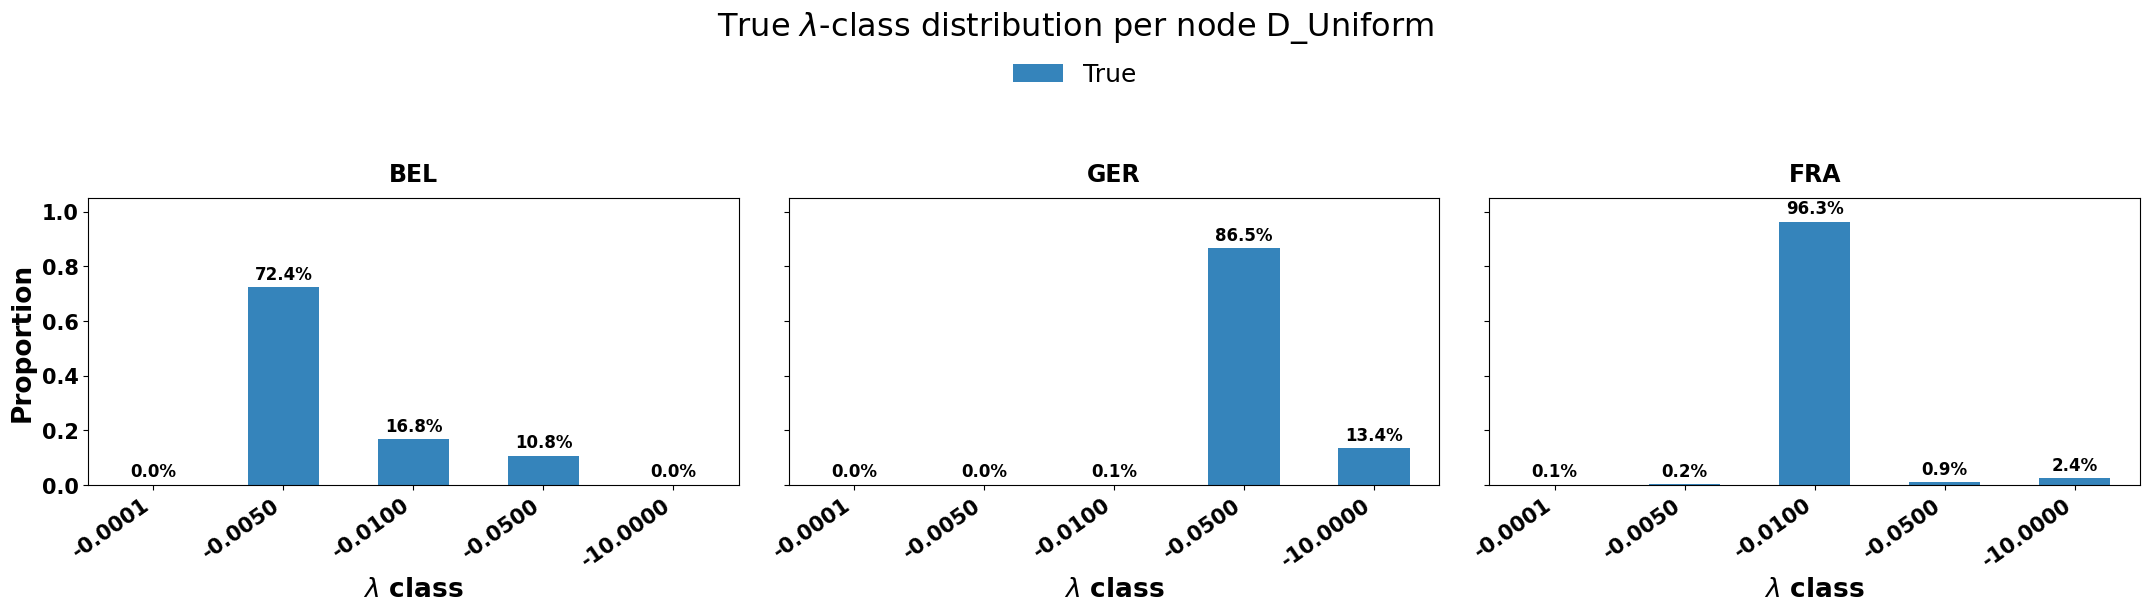

In [12]:
data_path = "data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
data = pickle.load(open(data_path, "rb"))

plot_lambda_true_dist(
    data=data,
    dual_net=dual_net,
    title=r"True $\lambda$-class distribution per node D_Uniform",
    save_name="true_lambda_distribution.png"
)

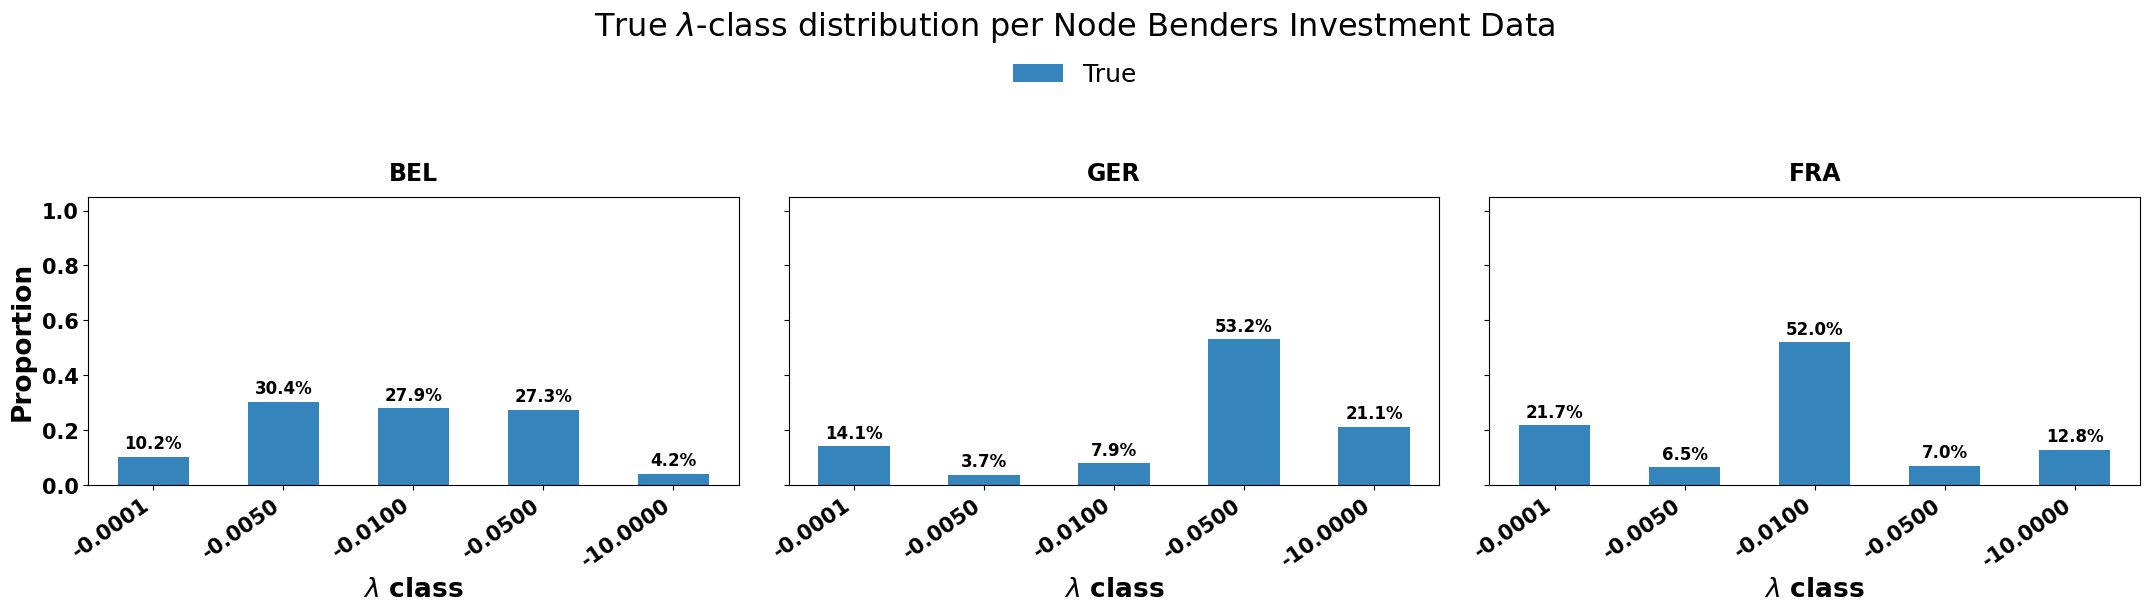

In [11]:
# BEnders Ecnountered Data

data_path = "data/ED_data/Benders_Encountered.pkl"
data = pickle.load(open(data_path, "rb"))

plot_lambda_true_dist(
    data=data,
    dual_net=dual_net,
    title=r"True $\lambda$-class distribution per Node Benders Investment Data",
    save_name="true_lambda_distribution.png"
)